In [1]:
#%pip install seaborn

In [2]:
#Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import timedelta

Задания на лабораторную работу
1.  Считать данные по ссылке (см выше)
2. Провести EDA  (разведочный анализ данных)
3.  сформировать набор данных для обучения
4. Разделить на train/test  (test - последняя неделя)
5. Сделать рекомендации:
5.1. Random
5.2. Popular
5.3. TopPopular ( personal popular + Popular)


In [5]:
# читаем наши три таблицы
df_users = pd.read_csv('KION_DATASET-main/data_original/users.csv')
df_items = pd.read_csv('KION_DATASET-main/data_original/items.csv')
df_interactions = pd.read_csv('KION_DATASET-main/interactions.csv')

In [6]:
# первые строки users
df_users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [7]:
# первые строки items
df_items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [8]:
# первые строки interactions
df_interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0


проведем EDA

In [9]:
# смотрим типы столбцов
df_users.info()
print()
df_items.info()
print()
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 n

In [10]:
# посмотрим, есть ли пропуски
print('users')
print(df_users.isna().sum())
print()

print('items')
print(df_items.isna().sum())
print()

print('interactions')
print(df_interactions.isna().sum())

users
user_id         0
age         14095
income      14776
sex         13831
kids_flg        0
dtype: int64

items
item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64

interactions
user_id            0
item_id            0
last_watch_dt      0
total_dur          1
watched_pct      268
dtype: int64


In [11]:
#описательная статистика
print('users')
print(df_users.describe(include='all'))
print()

print('items')
print(df_items.describe(include='all'))
print()

print('interactions')
print(df_interactions.describe(include='all'))

users
             user_id        age        income     sex       kids_flg
count   8.401970e+05     826102        825421  826366  840197.000000
unique           NaN          6             6       2            NaN
top              NaN  age_25_34  income_20_40       Ж            NaN
freq             NaN     233926        471519  425270            NaN
mean    5.487668e+05        NaN           NaN     NaN       0.301106
std     3.168841e+05        NaN           NaN     NaN       0.458739
min     0.000000e+00        NaN           NaN     NaN       0.000000
25%     2.740990e+05        NaN           NaN     NaN       0.000000
50%     5.488080e+05        NaN           NaN     NaN       0.000000
75%     8.232380e+05        NaN           NaN     NaN       1.000000
max     1.097558e+06        NaN           NaN     NaN       1.000000

items
             item_id content_type  title    title_orig  release_year  \
count   15963.000000        15963  15963         11218  15865.000000   
unique         

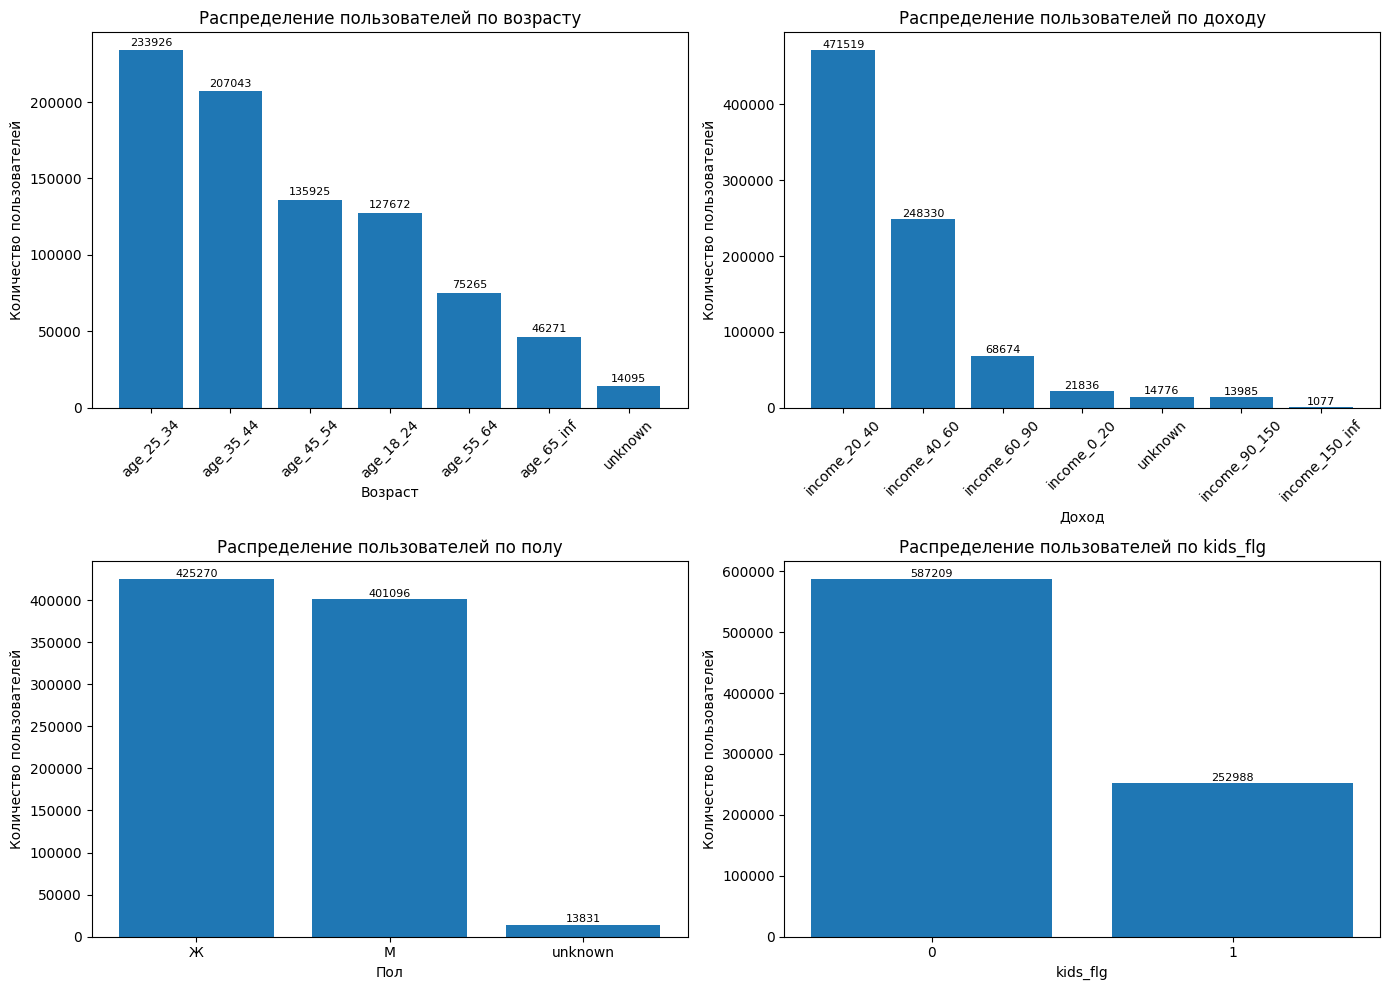

In [14]:
# сначала посмотрим на пользователей
# тут 4 простых распределения: возраст, доход, пол и наличие детей

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
age_counts = df_users['age'].fillna('unknown').value_counts()
bars = plt.bar(age_counts.index, age_counts.values)
plt.title('Распределение пользователей по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
for i, v in enumerate(age_counts.values):
    plt.text(i, v + 3000, str(v), ha='center', fontsize=8)

plt.subplot(2, 2, 2)
income_counts = df_users['income'].fillna('unknown').value_counts()
bars = plt.bar(income_counts.index, income_counts.values)
plt.title('Распределение пользователей по доходу')
plt.xlabel('Доход')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
for i, v in enumerate(income_counts.values):
    plt.text(i, v + 3000, str(v), ha='center', fontsize=8)

plt.subplot(2, 2, 3)
sex_counts = df_users['sex'].fillna('unknown').value_counts()
bars = plt.bar(sex_counts.index, sex_counts.values)
plt.title('Распределение пользователей по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пользователей')
for i, v in enumerate(sex_counts.values):
    plt.text(i, v + 3000, str(v), ha='center', fontsize=8)

plt.subplot(2, 2, 4)
kids_counts = df_users['kids_flg'].value_counts().sort_index()
bars = plt.bar(kids_counts.index.astype(str), kids_counts.values)
plt.title('Распределение пользователей по kids_flg')
plt.xlabel('kids_flg')
plt.ylabel('Количество пользователей')
for i, v in enumerate(kids_counts.values):
    plt.text(i, v + 3000, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

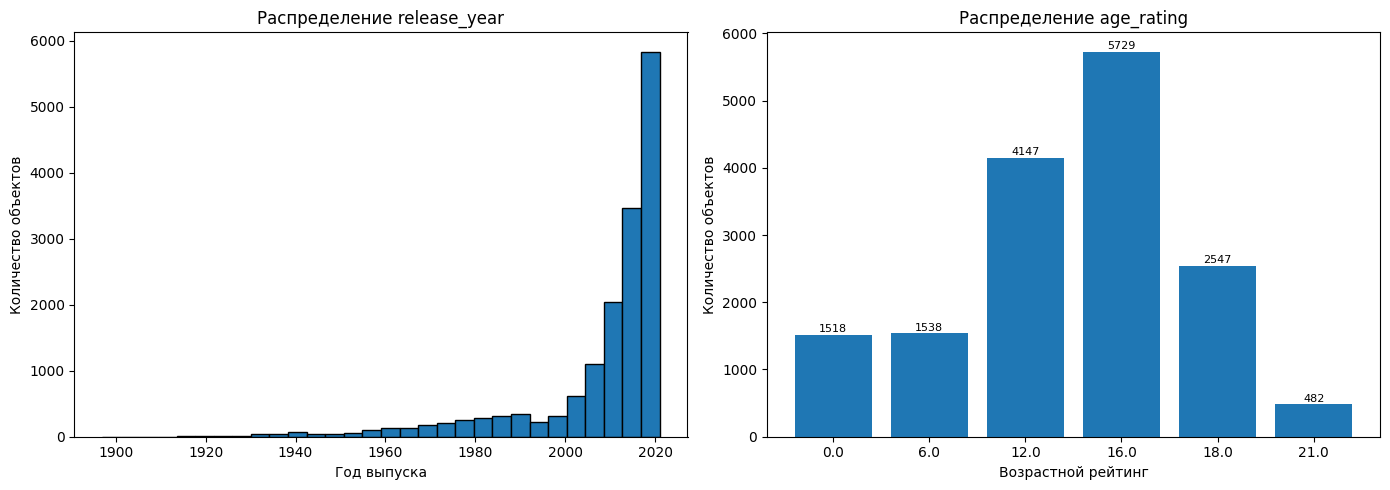

In [15]:
# теперь посмотрим на объекты
# здесь важно понять, из каких лет в основном контент
# и какие возрастные рейтинги встречаются чаще

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
release_year_data = df_items['release_year'].dropna()
plt.hist(release_year_data, bins=30, edgecolor='black')
plt.title('Распределение release_year')
plt.xlabel('Год выпуска')
plt.ylabel('Количество объектов')

plt.subplot(1, 2, 2)
age_rating_counts = df_items['age_rating'].dropna().value_counts().sort_index()
plt.bar(age_rating_counts.index.astype(str), age_rating_counts.values)
plt.title('Распределение age_rating')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Количество объектов')
for i, v in enumerate(age_rating_counts.values):
    plt.text(i, v + 40, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

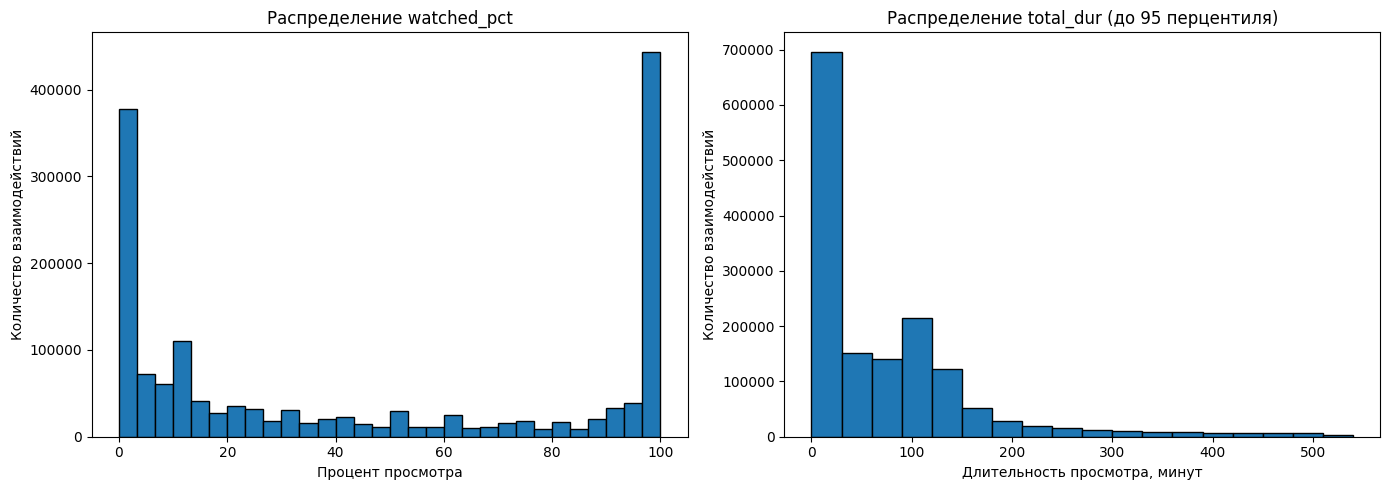

In [22]:
# тут смотрим на взаимодействия
# отдельно процент просмотра и отдельно длительность просмотра
# total_dur переводим в минуты, чтобы было понятнее
# чтобы график был читаемый, обрежем слишком большой хвост по 95 перцентилю

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
watched_pct_data = df_interactions['watched_pct'].dropna()
plt.hist(watched_pct_data, bins=30, edgecolor='black')
plt.title('Распределение watched_pct')
plt.xlabel('Процент просмотра')
plt.ylabel('Количество взаимодействий')

plt.subplot(1, 2, 2)
dur_min = df_interactions['total_dur'].dropna() / 60
q95 = dur_min.quantile(0.95)
dur_min_cut = dur_min[dur_min <= q95]

bins = np.arange(0, q95 + 30, 30)
plt.hist(dur_min_cut, bins=bins, edgecolor='black')

plt.title('Распределение total_dur (до 95 перцентиля)')
plt.xlabel('Длительность просмотра, минут')
plt.ylabel('Количество взаимодействий')

plt.tight_layout()
plt.show()

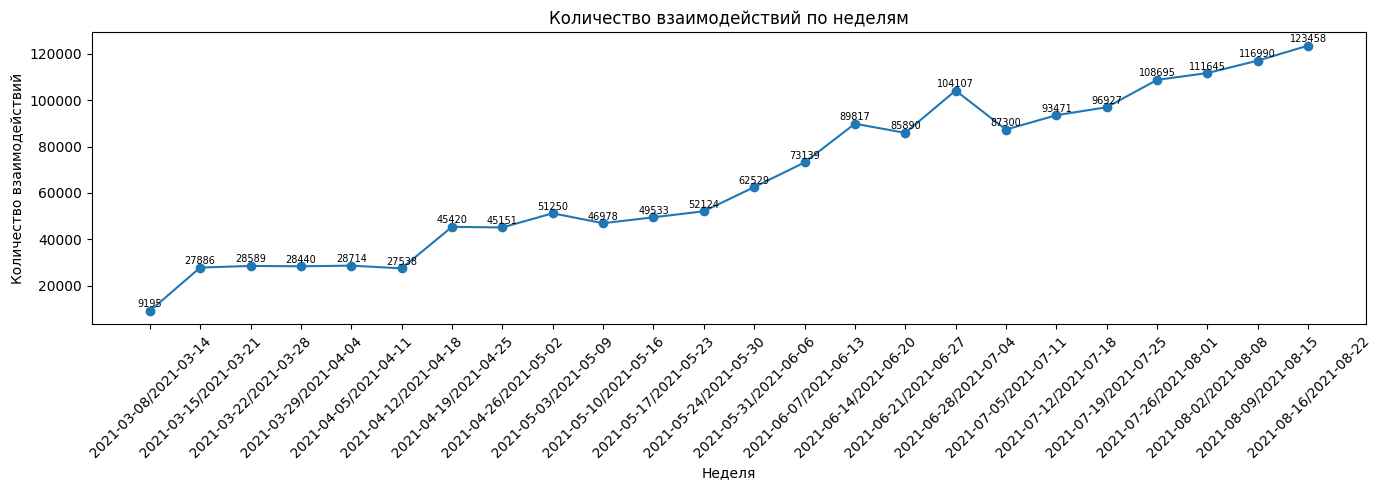

In [18]:
# теперь посмотрим активность по времени
# по дням график обычно получается слишком плотный, поэтому возьмем по неделям

df_interactions['last_watch_dt'] = pd.to_datetime(df_interactions['last_watch_dt'], errors='coerce')

tmp_dates = df_interactions.dropna(subset=['last_watch_dt']).copy()
tmp_dates['week'] = tmp_dates['last_watch_dt'].dt.to_period('W').astype(str)

week_counts = tmp_dates.groupby('week')['user_id'].count()

plt.figure(figsize=(14, 5))
plt.plot(week_counts.index, week_counts.values, marker='o')
plt.title('Количество взаимодействий по неделям')
plt.xlabel('Неделя')
plt.ylabel('Количество взаимодействий')
plt.xticks(rotation=45)

for i, v in enumerate(week_counts.values):
    plt.text(i, v + 1500, str(v), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

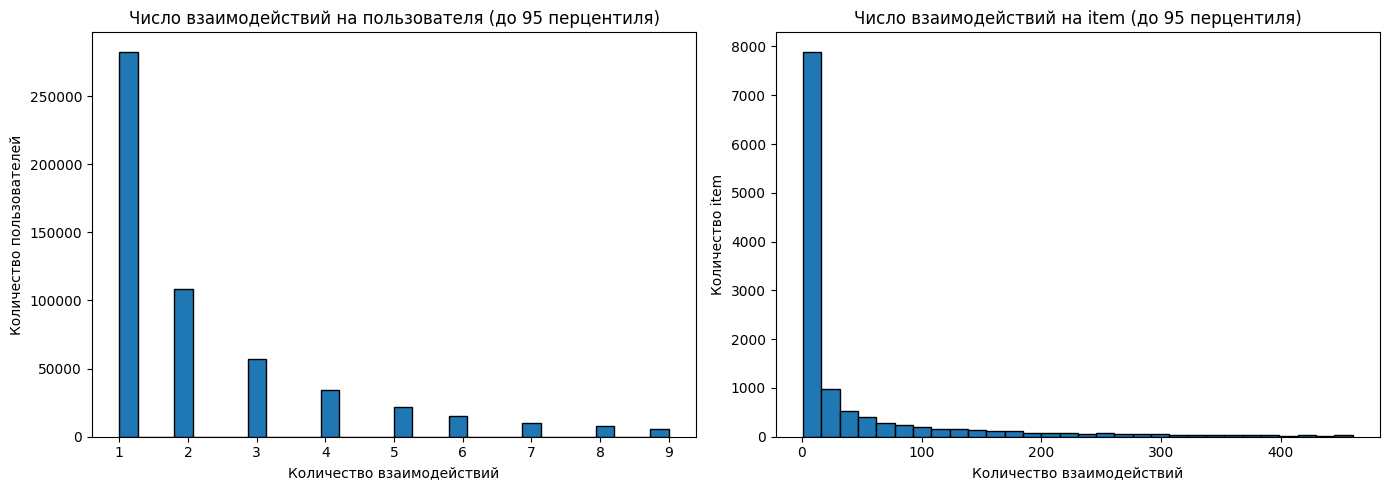

In [23]:
# здесь смотрим, сколько взаимодействий приходится:
# 1) на одного пользователя
# 2) на один item


user_interactions = df_interactions.groupby('user_id')['item_id'].count()
item_interactions = df_interactions.groupby('item_id')['user_id'].count()

user_q95 = user_interactions.quantile(0.95)
item_q95 = item_interactions.quantile(0.95)

user_interactions_cut = user_interactions[user_interactions <= user_q95]
item_interactions_cut = item_interactions[item_interactions <= item_q95]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(user_interactions_cut, bins=30, edgecolor='black')
plt.title('Число взаимодействий на пользователя (до 95 перцентиля)')
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество пользователей')

plt.subplot(1, 2, 2)
plt.hist(item_interactions_cut, bins=30, edgecolor='black')
plt.title('Число взаимодействий на item (до 95 перцентиля)')
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество item')

plt.tight_layout()
plt.show()

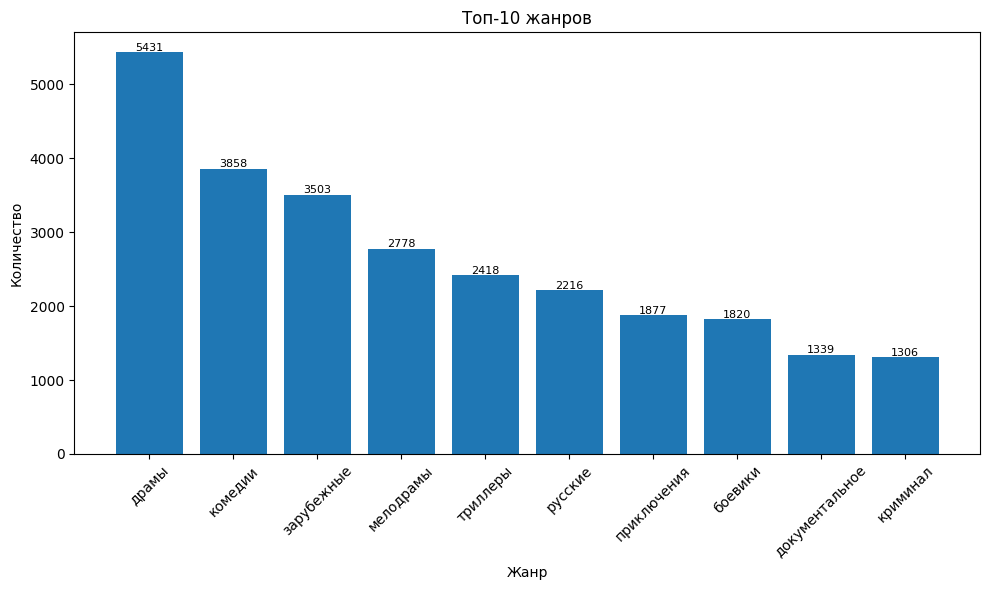

In [24]:
# посмотрим самые частые жанры


genres_series = df_items['genres'].dropna().str.split(', ')
genres_exploded = genres_series.explode()

top_genres = genres_exploded.value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_genres.index, top_genres.values)
plt.title('Топ-10 жанров')
plt.xlabel('Жанр')
plt.ylabel('Количество')
plt.xticks(rotation=45)

for i, v in enumerate(top_genres.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

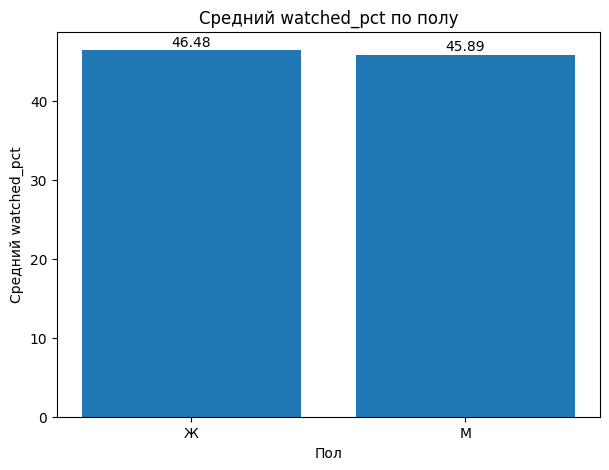

In [25]:
# посмотрим средний watched_pct по полу

tmp_merge = df_interactions.merge(df_users[['user_id', 'sex']], on='user_id', how='left')

mean_watch_by_sex = tmp_merge.groupby('sex')['watched_pct'].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar(mean_watch_by_sex.index.astype(str), mean_watch_by_sex.values)

plt.title('Средний watched_pct по полу')
plt.xlabel('Пол')
plt.ylabel('Средний watched_pct')

for i in range(len(mean_watch_by_sex)):
    val = round(mean_watch_by_sex.values[i], 2)
    plt.text(i, mean_watch_by_sex.values[i] + 0.5, str(val), ha='center')

plt.show()

In [26]:
# Общая статистика
print("\n=== Объединенный анализ ===")
merged = df_interactions.merge(df_users, on='user_id', how='left')
print("\nСредний % просмотра по возрасту:\n", merged.groupby('age')['watched_pct'].mean())
print("\nСредняя длительность по доходу:\n", merged.groupby('income')['total_dur'].mean())
print("\nСредний % просмотра по детям:\n", merged.groupby('kids_flg')['watched_pct'].mean())
print("\nСредний % просмотра по полу:\n", merged.groupby('sex')['watched_pct'].mean())


=== Объединенный анализ ===

Средний % просмотра по возрасту:
 age
age_18_24     46.043834
age_25_34     47.247716
age_35_44     47.521189
age_45_54     45.259258
age_55_64     43.076155
age_65_inf    40.033114
Name: watched_pct, dtype: float64

Средняя длительность по доходу:
 income
income_0_20        7076.551466
income_150_inf    12082.360615
income_20_40       7240.968511
income_40_60       7916.290080
income_60_90       9122.344623
income_90_150      9486.656524
Name: total_dur, dtype: float64

Средний % просмотра по детям:
 kids_flg
0.0    45.249022
1.0    47.913714
Name: watched_pct, dtype: float64

Средний % просмотра по полу:
 sex
Ж    46.480759
М    45.886042
Name: watched_pct, dtype: float64


In [28]:
numeric_cols = merged.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = merged[numeric_cols].corr()
print("\nКорреляции:\n", corr_matrix)


Корреляции:
               user_id   item_id  total_dur  watched_pct  kids_flg
user_id      1.000000 -0.000219  -0.000498    -0.001030  0.004366
item_id     -0.000219  1.000000   0.025535     0.028282  0.003447
total_dur   -0.000498  0.025535   1.000000     0.186691  0.007046
watched_pct -0.001030  0.028282   0.186691     1.000000  0.029906
kids_flg     0.004366  0.003447   0.007046     0.029906  1.000000


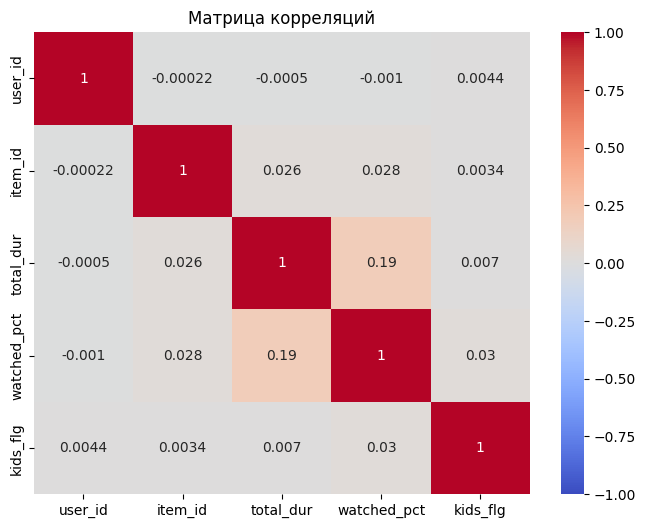

In [29]:
# Создание матрицы корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций')
plt.show()

<h2>Подготовка данных для обучения

In [30]:
# теперь начинаем готовить данные для рекомендаций
# переведем дату в нормальный формат и уберем плохие строки

df_interactions['last_watch_dt'] = pd.to_datetime(df_interactions['last_watch_dt'], errors='coerce')
df_interactions = df_interactions.dropna(subset=['last_watch_dt']).copy()

# оставим только более-менее хорошие просмотры
df_interactions = df_interactions[df_interactions['watched_pct'] > 50].copy()

print(df_interactions.shape)

(685055, 5)


In [31]:
# test = последняя неделя
max_date = df_interactions['last_watch_dt'].max()
border_date = max_date - timedelta(days=7)

df_train_all = df_interactions[df_interactions['last_watch_dt'] < border_date].copy()
df_test = df_interactions[df_interactions['last_watch_dt'] >= border_date].copy()

print(df_train_all.shape)
print(df_test.shape)
print(border_date)

(634955, 5)
(50100, 5)
2021-08-15 00:00:00


In [32]:
# для train берем последние 15 взаимодействий каждого пользователя

df_train_all = df_train_all.sort_values(['user_id', 'last_watch_dt'])
df_train = df_train_all.groupby('user_id').tail(15).copy()

print(df_train.shape)
df_train.head()

(620396, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
71779,2,7571,2021-05-20,6151.0,100.0
809786,2,11577,2021-05-21,4974.0,98.0
457283,2,4475,2021-05-30,7029.0,100.0
1053393,2,6774,2021-05-30,5663.0,92.0
163641,2,15266,2021-06-01,5422.0,100.0


In [33]:
# оставим только активных пользователей
# у которых есть хотя бы 2 взаимодействия и в train, и в test

train_counts = df_train['user_id'].value_counts()
test_counts = df_test['user_id'].value_counts()

active_train_users = set(train_counts[train_counts >= 2].index)
active_test_users = set(test_counts[test_counts >= 2].index)

good_users = active_train_users & active_test_users

df_train = df_train[df_train['user_id'].isin(good_users)].copy()
df_test = df_test[df_test['user_id'].isin(good_users)].copy()

print(df_train.shape)
print(df_test.shape)
print(len(good_users))

(22868, 5)
(10211, 5)
3692


In [34]:
# делаем test-таблицу:
# user_id и список item_id, которые реально были в test

data_test_group = df_test.groupby('user_id')['item_id'].unique().reset_index()
data_test_group.head()

,user_id,item_id
0,655,"[11188, 5199]"
1,835,"[5434, 11640]"
2,960,"[8636, 6809]"
3,977,"[3306, 2896, 11689]"
4,1785,"[9164, 10605]"


In [38]:
#Реализации метрик

def precision(recommended_list, bought_list):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    return precision


def precision_at_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    #assert len(bought_list) > len(recommended_list)
    bought_list = bought_list
    recommended_list = recommended_list[:k]
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    
    return precision




def money_precision_at_k(recommended_list, bought_list, prices_recommended, k=5):
        
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list[:k])
    flags = np.isin(recommended_list,bought_list)
    sm_bought=0
    for i in range(len(flags)):
        if flags[i]:
            sm_bought+=prices_recommended[i]
    m_precision=sm_bought/sum(prices_recommended)
    
    
    return m_precision


def recall(recommended_list, bought_list):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(bought_list, recommended_list)
    
    recall = flags.sum() / len(bought_list)
    
    return recall


def recall_at_k(recommended_list, bought_list, k=5):
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list[:k])
    
    flags = np.isin(bought_list, recommended_list)
    
    recall = flags.sum() / len(bought_list)
    
    return recall


def money_recall_at_k(recommended_list, bought_list, prices_recommended, prices_bought, k=5):
    prices_recommended=prices_recommended[:k]
    prince_recomend_relev=0
    for i in range(k):
        if recommended_list[i] in bought_list:
            prince_recomend_relev+=prices_recommended[i]
    m_recall=prince_recomend_relev/sum(prices_bought)
    
    
    return m_recall


def ap_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(recommended_list, bought_list)
    
    if sum(flags) == 0:
        return 0
    
    sum_ = 0
    for i in range(0, k-1):
        if flags[i] == True:
            p_k = precision_at_k(recommended_list, bought_list, k=i+1)
            sum_ += p_k
            
    result = sum_ / sum(flags)
    
    return result


def map_k(recommended_list, bought_list, k=5, u=1):
    _sum=0
    for i in range(u):
        _sum+=ap_k(recommended_list[i], bought_list[i], k=k)
    result=_sum/u
    return result

In [39]:
# будем считать метрики на 10 рекомендациях
k = 10

Random

In [40]:
#модель - random
# для каждого пользователя случайно выбираем 10 item


def random_rec(data_test_group, df_items, n=10):
    all_items = df_items['item_id'].unique().tolist()
    
    result = data_test_group[['user_id']].copy()
    recs = []
    
    for user in result['user_id']:
        random_items = random.sample(all_items, n)
        recs.append(random_items)
    
    result['random_recommendation'] = recs
    return result

In [41]:
# получаем random рекомендации

result_random = random_rec(data_test_group, df_items, n=10)

# добавляем реальные item из test
result_random = result_random.merge(data_test_group, on='user_id', how='left')

result_random.head()

,user_id,random_recommendation,item_id
0,655,"[12664, 14523, 8973, 11952, 3474, 6279, 14690,...","[11188, 5199]"
1,835,"[12765, 15145, 12046, 6771, 4574, 10347, 4798,...","[5434, 11640]"
2,960,"[314, 1351, 2929, 11498, 13511, 9197, 8235, 14...","[8636, 6809]"
3,977,"[15247, 2282, 3426, 9017, 15660, 4140, 4344, 6...","[3306, 2896, 11689]"
4,1785,"[5272, 5409, 7031, 2427, 8588, 855, 15200, 143...","[9164, 10605]"


In [42]:
#  считаем метрики для random
# money-метрики не считаем, потому что у нас нет цен


random_precision_10 = 0
random_recall_10 = 0

for i in range(len(result_random)):
    rec_list = result_random['random_recommendation'].iloc[i]
    true_list = result_random['item_id'].iloc[i]
    
    random_precision_10 += precision_at_k(rec_list, true_list, k=10)
    random_recall_10 += recall_at_k(rec_list, true_list, k=10)

random_precision_10 = random_precision_10 / len(result_random)
random_recall_10 = random_recall_10 / len(result_random)

random_map_10 = map_k(
    result_random['random_recommendation'].tolist(),
    result_random['item_id'].tolist(),
    k=10,
    u=len(result_random)
)

print('random precision@10 =', random_precision_10)
print('random recall@10 =', random_recall_10)
print('random map@10 =', random_map_10)

random precision@10 = 0.00010834236186348862
random recall@10 = 0.0003235223305645841
random map@10 = 0.0002008847959552185


Popular

In [43]:
# модель - popular
#  берем самые популярные item из train
# и рекомендуем их всем одинаково


popular_items = df_train['item_id'].value_counts().index.tolist()[:10]

result_popular = data_test_group[['user_id']].copy()

popular_recs = []
for i in range(len(result_popular)):
    popular_recs.append(popular_items)

result_popular['popular_recommendation'] = popular_recs
result_popular = result_popular.merge(data_test_group, on='user_id', how='left')

result_popular.head()

,user_id,popular_recommendation,item_id
0,655,"[9728, 13865, 3734, 10440, 15297, 3182, 7571, ...","[11188, 5199]"
1,835,"[9728, 13865, 3734, 10440, 15297, 3182, 7571, ...","[5434, 11640]"
2,960,"[9728, 13865, 3734, 10440, 15297, 3182, 7571, ...","[8636, 6809]"
3,977,"[9728, 13865, 3734, 10440, 15297, 3182, 7571, ...","[3306, 2896, 11689]"
4,1785,"[9728, 13865, 3734, 10440, 15297, 3182, 7571, ...","[9164, 10605]"


In [44]:
# считаем метрики для popular
# precision@10, recall@10 и map@10


popular_precision_10 = 0
popular_recall_10 = 0

for i in range(len(result_popular)):
    rec_list = result_popular['popular_recommendation'].iloc[i]
    true_list = result_popular['item_id'].iloc[i]
    
    popular_precision_10 += precision_at_k(rec_list, true_list, k=10)
    popular_recall_10 += recall_at_k(rec_list, true_list, k=10)

popular_precision_10 = popular_precision_10 / len(result_popular)
popular_recall_10 = popular_recall_10 / len(result_popular)

popular_map_10 = map_k(
    result_popular['popular_recommendation'].tolist(),
    result_popular['item_id'].tolist(),
    k=10,
    u=len(result_popular)
)

print('popular precision@10 =', popular_precision_10)
print('popular recall@10 =', popular_recall_10)
print('popular map@10 =', popular_map_10)

popular precision@10 = 0.015113759479956787
popular recall@10 = 0.059838679512975335
popular map@10 = 0.05919034506182385


Toppopular

In [45]:
# часть рекомендаций берем из личной истории пользователя,
# а остальное добиваем самыми популярными item

global_top = df_train['item_id'].value_counts().index.tolist()

In [46]:
# строим toppopular рекомендации

result_toppopular = data_test_group[['user_id']].copy()

all_recs = []

for user in result_toppopular['user_id']:
    user_data = df_train[df_train['user_id'] == user]
    
    # берем несколько самых частых item пользователя
    personal_top = user_data['item_id'].value_counts().index.tolist()[:4]
    
    final_rec = personal_top.copy()
    
    # добавляем глобально популярные item, которых еще нет
    for item in global_top:
        if item not in final_rec:
            final_rec.append(item)
        if len(final_rec) == 10:
            break
    
    all_recs.append(final_rec)

result_toppopular['toppopular_recommendation'] = all_recs
result_toppopular = result_toppopular.merge(data_test_group, on='user_id', how='left')

result_toppopular.head()

,user_id,toppopular_recommendation,item_id
0,655,"[6273, 4946, 15531, 11899, 9728, 13865, 3734, ...","[11188, 5199]"
1,835,"[13159, 15297, 6143, 3792, 9728, 13865, 3734, ...","[5434, 11640]"
2,960,"[10440, 1527, 14915, 8618, 9728, 13865, 3734, ...","[8636, 6809]"
3,977,"[8821, 15464, 9728, 13865, 3734, 10440, 15297,...","[3306, 2896, 11689]"
4,1785,"[4718, 13243, 12908, 1290, 9728, 13865, 3734, ...","[9164, 10605]"


In [47]:
#  считаем метрики для toppopular
#  precision@10, recall@10 и map@10


toppopular_precision_10 = 0
toppopular_recall_10 = 0

for i in range(len(result_toppopular)):
    rec_list = result_toppopular['toppopular_recommendation'].iloc[i]
    true_list = result_toppopular['item_id'].iloc[i]
    
    toppopular_precision_10 += precision_at_k(rec_list, true_list, k=10)
    toppopular_recall_10 += recall_at_k(rec_list, true_list, k=10)

toppopular_precision_10 = toppopular_precision_10 / len(result_toppopular)
toppopular_recall_10 = toppopular_recall_10 / len(result_toppopular)

toppopular_map_10 = map_k(
    result_toppopular['toppopular_recommendation'].tolist(),
    result_toppopular['item_id'].tolist(),
    k=10,
    u=len(result_toppopular)
)

print('toppopular precision@10 =', toppopular_precision_10)
print('toppopular recall@10 =', toppopular_recall_10)
print('toppopular map@10 =', toppopular_map_10)

toppopular precision@10 = 0.01286565547128937
toppopular recall@10 = 0.051722568315878216
toppopular map@10 = 0.01986830169048484


In [48]:
#  собираем все результаты в одну таблицу


result_table = pd.DataFrame({
    'model': ['random', 'popular', 'toppopular'],
    'precision@10': [random_precision_10, popular_precision_10, toppopular_precision_10],
    'recall@10': [random_recall_10, popular_recall_10, toppopular_recall_10],
    'map@10': [random_map_10, popular_map_10, toppopular_map_10]
})

result_table

,model,precision@10,recall@10,map@10
0,random,0.000108,0.000324,0.000201
1,popular,0.015114,0.059839,0.059190
2,toppopular,0.012866,0.051723,0.019868


Random работает хуже остальных, потому что рекомендации выбираются случайно.
Popular обычно лучше random, потому что использует самые частые item из train.
TopPopular обычно показывает лучший результат, потому что тут учитывается и история пользователя, и общая популярность, но в нашем случае показала себя хуже Popular.